# Case Study 6
## Nikitha Joshy & Teammate
Analysis of global migration, skill flows and economic inclusion in
OECD countries from 2000 - 2024


In [ ]:
#!pip install pandasdmx

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Setup and Utility Functions

In [ ]:
base = all  # your root path to the DIOC folders

def read_csv_robust(path):
    # Handles odd encodings and separators; falls back gracefully
    for args in [
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "latin1", "sep": ","},
        {"encoding": "utf-8", "sep": ";"},
        {"encoding": "latin1", "sep": ";"},
    ]:
        try:
            return pd.read_csv(path, **args)
        except Exception:
            continue
    raise RuntimeError(f"Could not read CSV: {path}")

def read_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in [".csv", ".txt"]:
        return read_csv_robust(path)
    elif ext in [".xlsx", ".xls"]:
        # Most TOP100 Excel files have a first sheet with the table
        try:
            return pd.read_excel(path, sheet_name=0)
        except Exception:
            # If sheet names exist but the first isn’t the right one, show available sheets
            xls = pd.ExcelFile(path)
            print(f"  Sheets in {os.path.basename(path)}: {xls.sheet_names}")
            # Try the first non-empty sheet
            for s in xls.sheet_names:
                df = pd.read_excel(path, sheet_name=s)
                if not df.empty:
                    return df
            # Fallback: return first sheet anyway
            return pd.read_excel(path, sheet_name=xls.sheet_names[0])
    else:
        raise ValueError(f"Unsupported file type: {path}")

In [ ]:
def aggregate_skill(df, year):
    # Harmonize education codes
    edu_map = {
        1: "Low", 2: "Medium", 3: "High", 34: "High", 99: "Unknown",
        "ISCED 0/1/2": "Low", "ISCED 3/4": "Medium", "ISCED 5/6/7/8": "High", "Unknown": "Unknown"
    }
    df["edu_level"] = df["edu_lfs"].map(edu_map)

    # Aggregate by country + skill level
    agg = df.groupby(["country","edu_level"], as_index=False)["number"].sum()

    # Compute totals per country
    totals = agg.groupby("country", as_index=False)["number"].sum().rename(columns={"number":"total"})

    # Merge totals back in
    merged = agg.merge(totals, on="country")
    merged["share"] = merged["number"] / merged["total"] * 100
    merged["year"] = year
    return merged

## Load and Process DIOC Data (2000-2020)


In [ ]:


base = '/content/drive/Shared drives/Case Study 6/DIOC Data'  # Ensure base is explicitly a string

targets = [
    ("DIOC 2000-01", "FILE_A_1_T.csv"),
    ("DIOC 2005-06", "T1.2_2005.CSV"),
    ("DIOC 2010-11", "DIOC_2010_11_File_A_quater_REV.csv"),
    ("DIOC 2015-16", "DIOC_2015_16_File_A_1.csv"),
    ("DIOC 2020-21", "t1_TOP100.xlsx"),
]

aggregated_dfs = []

for folder_name, filename in targets:
    file_path = os.path.join(base, folder_name, filename)

    # Extract the year from the folder name (e.g., "DIOC 2000-01" -> 2000)
    year_str = folder_name.split(' ')[1].split('-')[0]
    year = int(year_str)

    print(f"Processing {folder_name}/{filename} for year {year}...")
    try:
        df = read_file(file_path)
        agg_df = aggregate_skill(df, year)
        aggregated_dfs.append(agg_df)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

panel = pd.concat(aggregated_dfs, ignore_index=True)
print("Successfully loaded and aggregated DIOC data into 'panel' DataFrame.")
print(panel.head())

Processing DIOC 2000-01/FILE_A_1_T.csv for year 2000...
Processing DIOC 2005-06/T1.2_2005.CSV for year 2005...
Processing DIOC 2010-11/DIOC_2010_11_File_A_quater_REV.csv for year 2010...
Processing DIOC 2015-16/DIOC_2015_16_File_A_1.csv for year 2015...
Processing DIOC 2020-21/t1_TOP100.xlsx for year 2020...
Successfully loaded and aggregated DIOC data into 'panel' DataFrame.
  country edu_level     number       total      share  year
0     AUS      High  2811272.0  14856774.0  18.922493  2000
1     AUS       Low  6144787.0  14856774.0  41.360170  2000
2     AUS    Medium  4197232.0  14856774.0  28.251301  2000
3     AUS   Unknown  1703483.0  14856774.0  11.466036  2000
4     AUT      High   731414.0   6679444.0  10.950223  2000


## Analyze OECD Skill Migration Trends (Guiding Question 1)



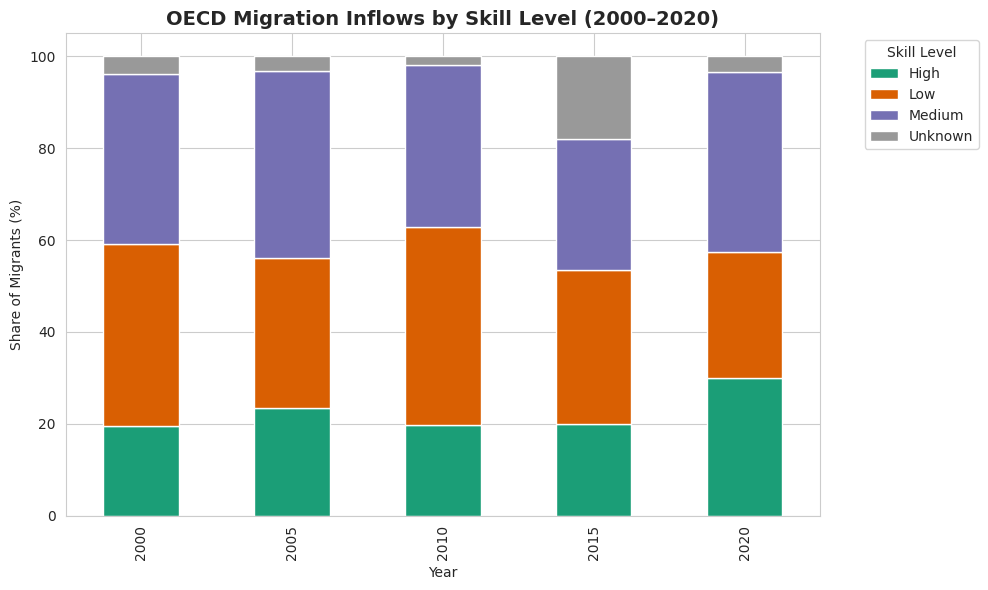

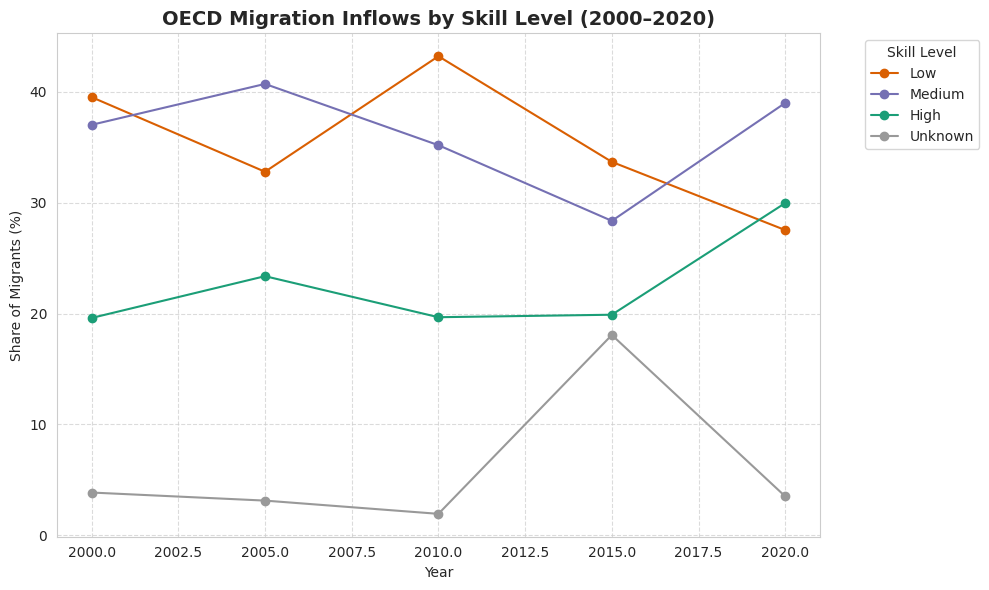

In [ ]:
import matplotlib.pyplot as plt

# Collapse to OECD totals
panel_oecd = panel.groupby(["year","edu_level"], as_index=False)["number"].sum()

# Compute shares per year
totals = panel_oecd.groupby("year", as_index=False)["number"].sum().rename(columns={"number":"total"})
panel_oecd = panel_oecd.merge(totals, on="year")
panel_oecd["share"] = panel_oecd["number"] / panel_oecd["total"] * 100

# Pivot for plotting
pivot_oecd = panel_oecd.pivot(index="year", columns="edu_level", values="share")

# --- Stacked bar chart (OECD totals) ---
pivot_oecd.plot(kind="bar", stacked=True, figsize=(10,6),
                color={"Low":"#d95f02","Medium":"#7570b3","High":"#1b9e77","Unknown":"#999999"})
plt.title("OECD Migration Inflows by Skill Level (2000–2020)", fontsize=14, weight="bold")
plt.ylabel("Share of Migrants (%)")
plt.xlabel("Year")
plt.legend(title="Skill Level", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# --- Line chart (OECD totals) ---
plt.figure(figsize=(10,6))
for level, color in zip(["Low","Medium","High","Unknown"],
                        ["#d95f02","#7570b3","#1b9e77","#999999"]):
    if level in pivot_oecd.columns:
        plt.plot(pivot_oecd.index, pivot_oecd[level],
                 marker="o", label=level, color=color)

plt.title("OECD Migration Inflows by Skill Level (2000–2020)", fontsize=14, weight="bold")
plt.ylabel("Share of Migrants (%)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Skill Level", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

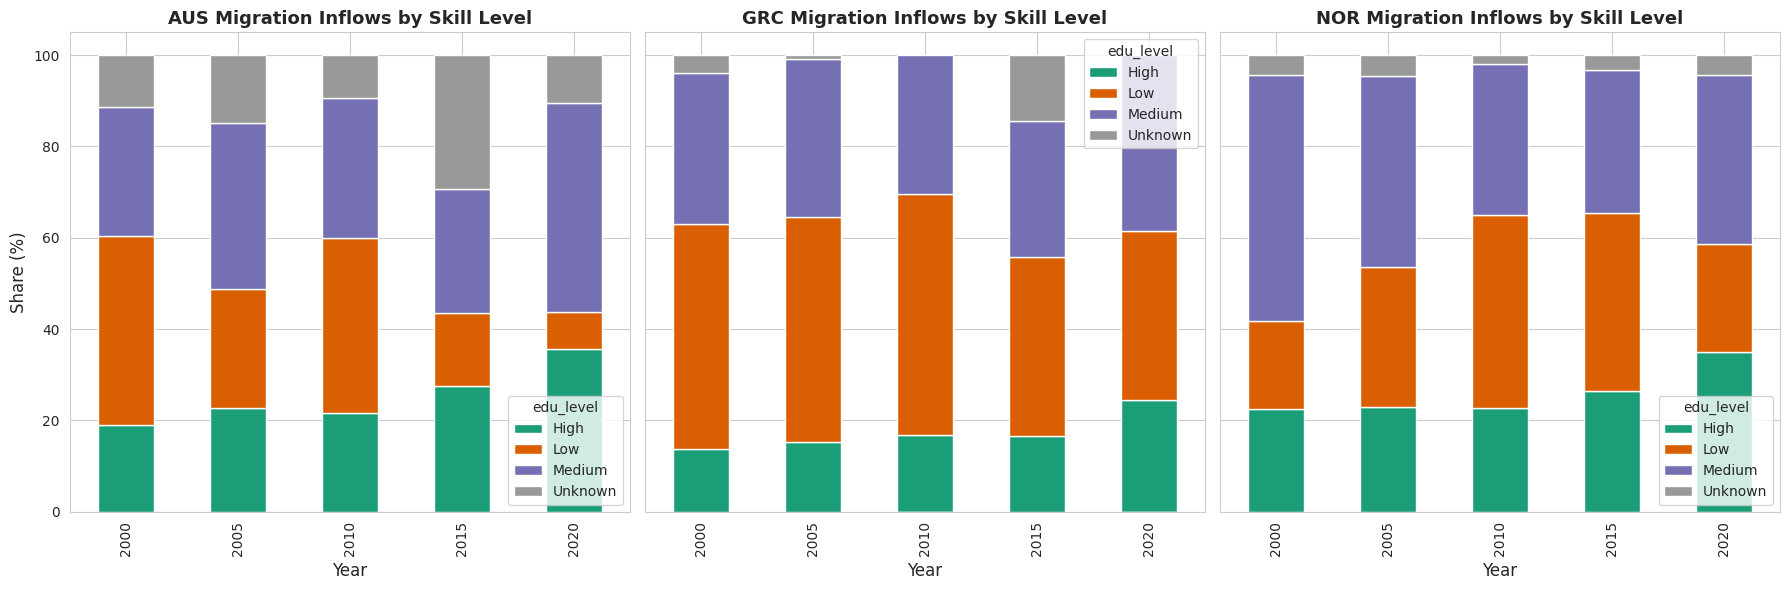

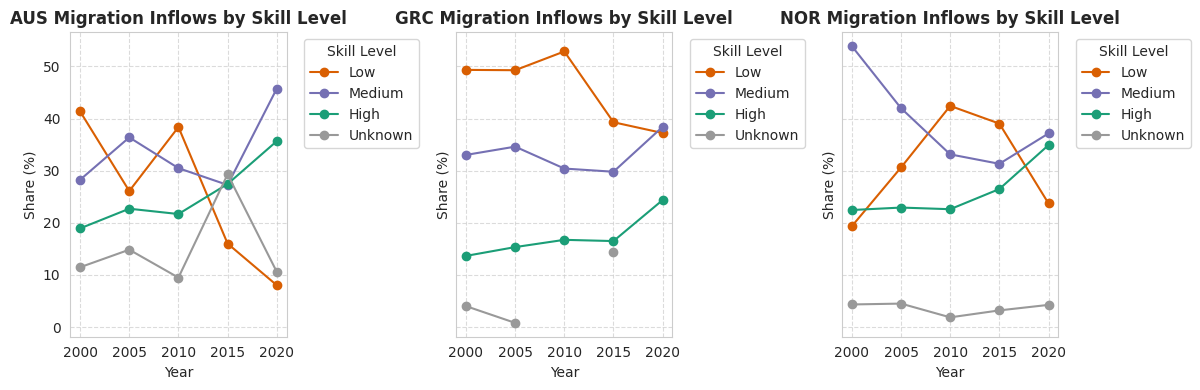

In [ ]:
selected = panel[panel["country"].isin(["AUS","GRC","NOR"])]

pivot_country = selected.pivot_table(index="year", columns=["country","edu_level"], values="share")

# Plot each country separately
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

colors = {"Low":"#d95f02","Medium":"#7570b3","High":"#1b9e77","Unknown":"#999999"}

for ax, country in zip(axes, ["AUS","GRC","NOR"]):
    pivot_country[country].plot(kind="bar", stacked=True, ax=ax, color=colors)
    ax.set_title(f"{country} Migration Inflows by Skill Level", fontsize=13, weight="bold")
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Share (%)", fontsize=12)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True)
colors = {"Low":"#d95f02","Medium":"#7570b3","High":"#1b9e77","Unknown":"#999999"}

for ax, country in zip(axes, ["AUS","GRC","NOR"]):
    for level in ["Low","Medium","High","Unknown"]:
        if (country, level) in pivot_country.columns:
            ax.plot(pivot_country.index, pivot_country[(country, level)],
                    marker="o", label=level, color=colors[level])
    ax.set_title(f"{country} Migration Inflows by Skill Level", fontsize=12, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Share (%)")
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend(title="Skill Level", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

## Load and Process R&D Expenditure Data


In [ ]:
# US Dollars PPP converted.
RD = '/content/drive/Shareddrives/Case Study 6/R&D Data/Gross domestic expenditure.csv'
dom_expenditure = pd.read_csv(RD, header=0)
dom_expenditure = dom_expenditure.drop(0)
dom_expenditure = dom_expenditure.rename(columns={
    "Time period": "country",
    "Unnamed: 1": "unit",
    "Unnamed: 2": "price_base"
})

dom_expenditure.head()

,country,unit,price_base,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,Australia USD,"US dollars, PPP converted, Millions, 2020",Constant prices,"12,550.11",NaN,"15,028.53",NaN,"16,947.50",NaN,"20,943.33",...,NaN,"24,997.21",NaN,"25,103.46",NaN,"25,642.46",NaN,"25,263.78",NaN,NaN
2,Australia USD,"US dollars, PPP converted, Millions",Current prices,"7,939.38",NaN,"9,885.30",NaN,"11,700.50",NaN,"15,525.94",...,NaN,"21,151.52",NaN,"22,376.19",NaN,"24,397.41",NaN,"27,764.08",NaN,NaN
3,Greece USD,"US dollars, PPP converted, Millions, 2020",Constant prices,NaN,"1,985.68",NaN,"2,138.64","2,169.78","2,404.60","2,465.63",...,"2,784.75","3,192.65","3,303.20","3,830.66","4,105.04","4,392.55","4,703.81","4,921.44","5,362.42","5,551.22"
4,Greece USD,"US dollars, PPP converted, Millions",Current prices,NaN,"1,273.84",NaN,"1,427.33","1,470.81","1,627.03","1,765.59",...,"2,436.03","2,798.16","2,980.36","3,544.84","3,858.16","4,321.22","4,703.81","5,080.42","6,007.77","6,403.42"
5,Norway USD,"US dollars, PPP converted, Millions, 2020",Constant prices,NaN,"4,377.20","4,478.77","4,662.55","4,607.24","4,816.63","5,076.07",...,"6,566.15","7,194.92","7,421.91","7,925.71","8,072.50","8,296.62","8,102.60","8,282.07","8,544.60","8,570.10"


In [ ]:
# Melt into long format
dom_long = dom_expenditure.melt(
    id_vars=["country","unit","price_base"],
    var_name="year",
    value_name="gerd_value"
)

# Remove commas from the numeric strings
dom_long["gerd_value"] = dom_long["gerd_value"].str.replace(",", "", regex=True)

# Convert to numeric
dom_long["year"] = pd.to_numeric(dom_long["year"], errors="coerce")
dom_long["gerd_value"] = pd.to_numeric(dom_long["gerd_value"], errors="coerce")

# Drop missing values
dom_long = dom_long.dropna(subset=["gerd_value"])

dom_long.head()

,country,unit,price_base,year,gerd_value
0,Australia USD,"US dollars, PPP converted, Millions, 2020",Constant prices,2000,12550.11
1,Australia USD,"US dollars, PPP converted, Millions",Current prices,2000,7939.38
8,Greece USD,"US dollars, PPP converted, Millions, 2020",Constant prices,2001,1985.68
9,Greece USD,"US dollars, PPP converted, Millions",Current prices,2001,1273.84
10,Norway USD,"US dollars, PPP converted, Millions, 2020",Constant prices,2001,4377.20


In [ ]:
dom_long["country"] = dom_long["country"].str.replace(" USD", "", regex=False)

# Aggregate in case of duplicates or different unit/price_base values for the same country-year
gerd_agg = dom_long.groupby(["country","year"], as_index=False)["gerd_value"].sum()

# Filter only the countries of interest
countries_full = ["Australia", "Greece", "Norway"]
gerd_selected = gerd_agg[gerd_agg["country"].isin(countries_full)]

# Pivot GERD data
gerd_pivot = gerd_selected.pivot(index="year", columns="country", values="gerd_value").reset_index()

# Rename GERD columns to match full names with '_gerd' suffix
gerd_pivot = gerd_pivot.rename(columns={
    "Australia": "Australia_gerd",
    "Greece": "Greece_gerd",
    "Norway": "Norway_gerd"
})

print(gerd_pivot.head())

country  year  Australia_gerd  Greece_gerd  Norway_gerd
0        2000        20489.49          NaN          NaN
1        2001             NaN      3259.52      7041.56
2        2002        24913.83          NaN      7287.73
3        2003             NaN      3565.97      7621.71
4        2004        28648.00      3640.59      7624.39


## Merge Migration and R&D Data

In [ ]:
import pandas as pd

# 1. Filter the panel DataFrame to select only rows where the edu_level is 'High'
high_skill = panel[panel["edu_level"]=="High"]

# 2. Pivot the high_skill DataFrame
high_skill_pivot = high_skill.pivot(index="year", columns="country", values="share").reset_index()

# 3. Create a dictionary to map country codes to their full country names
code_to_name = {"AUS":"Australia","GRC":"Greece","NOR":"Norway"}

# 4. Rename the country code columns in the high_skill_pivot DataFrame
high_skill_pivot_renamed = high_skill_pivot.rename(columns=code_to_name)

# 5. Merge the high_skill_pivot_renamed DataFrame with the gerd_pivot DataFrame
eda_merge = pd.merge(
    high_skill_pivot_renamed,
    gerd_pivot,
    on="year",
    how="outer"
).sort_values("year").reset_index(drop=True)

# 6. Print the head of the eda_merge DataFrame
print(eda_merge.head())

country  year  Australia        AUT        BEL  BGR        CAN        CHE  \
0        2000  18.922493  10.950223  21.216556  NaN  32.915885  16.713396   
1        2001        NaN        NaN        NaN  NaN        NaN        NaN   
2        2002        NaN        NaN        NaN  NaN        NaN        NaN   
3        2003        NaN        NaN        NaN  NaN        NaN        NaN   
4        2004        NaN        NaN        NaN  NaN        NaN        NaN   

country  CHL  COL  CSFR-CZE  ...  ROU  RUS        SVK  SVN        SWE  \
0        NaN  NaN       NaN  ...  NaN  NaN  10.324995  NaN  22.605747   
1        NaN  NaN       NaN  ...  NaN  NaN        NaN  NaN        NaN   
2        NaN  NaN       NaN  ...  NaN  NaN        NaN  NaN        NaN   
3        NaN  NaN       NaN  ...  NaN  NaN        NaN  NaN        NaN   
4        NaN  NaN       NaN  ...  NaN  NaN        NaN  NaN        NaN   

country       TUR        USA  Australia_gerd  Greece_gerd  Norway_gerd  
0        6.624023  27.253

## Visualize Skilled Migration vs. R&D Investment

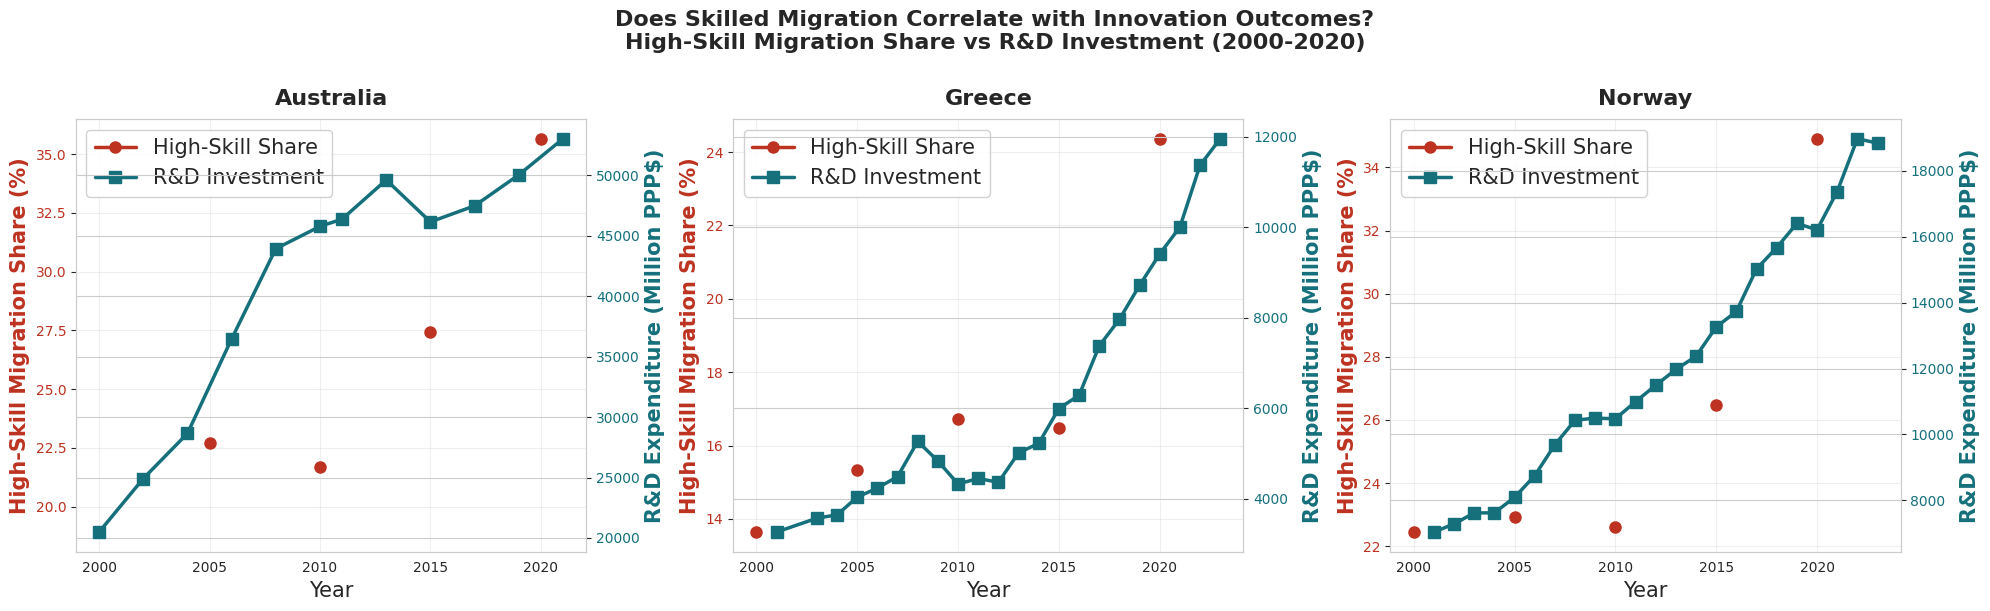

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Select only columns for the 3 countries + GERD
plot_data = eda_merge[["year", "Australia", "Greece", "Norway",
                       "Australia_gerd", "Greece_gerd", "Norway_gerd"]]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

countries_info = [
    ("Australia", "Australia", "Australia_gerd", "#bd3220", "#15707c"),
    ("Greece", "Greece", "Greece_gerd", "#bd3220", "#15707c"),
    ("Norway", "Norway", "Norway_gerd","#bd3220", "#15707c")
]

for ax, (code, name, gerd_col, color_mig, color_gerd) in zip(axes, countries_info):
    ax2 = ax.twinx()

    # High-skilled migration (left axis)
    line1 = ax.plot(plot_data["year"], plot_data[code],
                    marker="o", linewidth=2.5, markersize=8,
                    color=color_mig, label="High-Skill Share", zorder=3)
    ax.set_ylabel("High-Skill Migration Share (%)", color=color_mig, fontsize=15, fontweight="bold")
    ax.set_xlabel("Year", fontsize=15)
    ax.set_title(name, fontsize=16, fontweight="bold", pad=10)
    ax.tick_params(axis='y', labelcolor=color_mig)
    ax.grid(True, alpha=0.3)

    # GERD expenditure (right axis)
    valid_idx = plot_data[gerd_col].notna()
    line2 = ax2.plot(plot_data[valid_idx]["year"], plot_data[valid_idx][gerd_col],
                     marker="s", linewidth=2.5, markersize=8,
                     color=color_gerd, label="R&D Investment", zorder=3)
    ax2.set_ylabel("R&D Expenditure (Million PPP$)", color=color_gerd, fontsize=15, fontweight="bold")
    ax2.tick_params(axis='y', labelcolor=color_gerd)

    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc="upper left", framealpha=0.9, fontsize=15)

plt.suptitle("Does Skilled Migration Correlate with Innovation Outcomes?\nHigh-Skill Migration Share vs R&D Investment (2000-2020)",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
def correlation_analysis(data, countries):

    results = []

    for country in countries:
        # Extract columns for this country
        mig_col = country
        gerd_col = f"{country}_gerd"

        if mig_col in data.columns and gerd_col in data.columns:
            # Remove NaN values
            valid = data[[mig_col, gerd_col]].dropna()

            if len(valid) > 2:
                # Pearson correlation
                pearson_r, pearson_p = stats.pearsonr(valid[mig_col], valid[gerd_col])

                # Spearman correlation (rank-based, more robust)
                spearman_r, spearman_p = stats.spearmanr(valid[mig_col], valid[gerd_col])

                results.append({
                    'Country': country,
                    'Pearson_r': pearson_r,
                    'Pearson_p': pearson_p,
                    'Spearman_r': spearman_r,
                    'Spearman_p': spearman_p,
                    'N_observations': len(valid)
                })

    return pd.DataFrame(results)

# Execute
corr_results = correlation_analysis(eda_merge, ["Australia", "Greece", "Norway"])
print("=" * 70)
print("CORRELATION ANALYSIS: High-Skill Migration vs R&D Investment")
print("=" * 70)
print(corr_results.to_string(index=False))
print("\nInterpretation:")
print("  • r > 0.7:  Strong positive correlation")
print("  • r > 0.4:  Moderate positive correlation")
print("  • r < 0.3:  Weak or no correlation")
print("  • p < 0.05: Statistically significant at 5% level")


CORRELATION ANALYSIS: High-Skill Migration vs R&D Investment
  Country  Pearson_r  Pearson_p  Spearman_r  Spearman_p  N_observations
Australia   0.756751   0.453571         1.0         0.0               3
   Greece   0.951384   0.048616         0.8         0.2               4
   Norway   0.916987   0.083013         0.8         0.2               4

Interpretation:
  • r > 0.7:  Strong positive correlation
  • r > 0.4:  Moderate positive correlation
  • r < 0.3:  Weak or no correlation
  • p < 0.05: Statistically significant at 5% level


Greece: Statistically Significant, STRONG (r=0.951, p<0.05)

Norway: Borderline Significant, VERY STRONG (r=0.917, p=0.083)

Australia: Not Significant, Strong (r=0.757, p=0.45)

## Migrant Skill Flows and Labor Market Integration

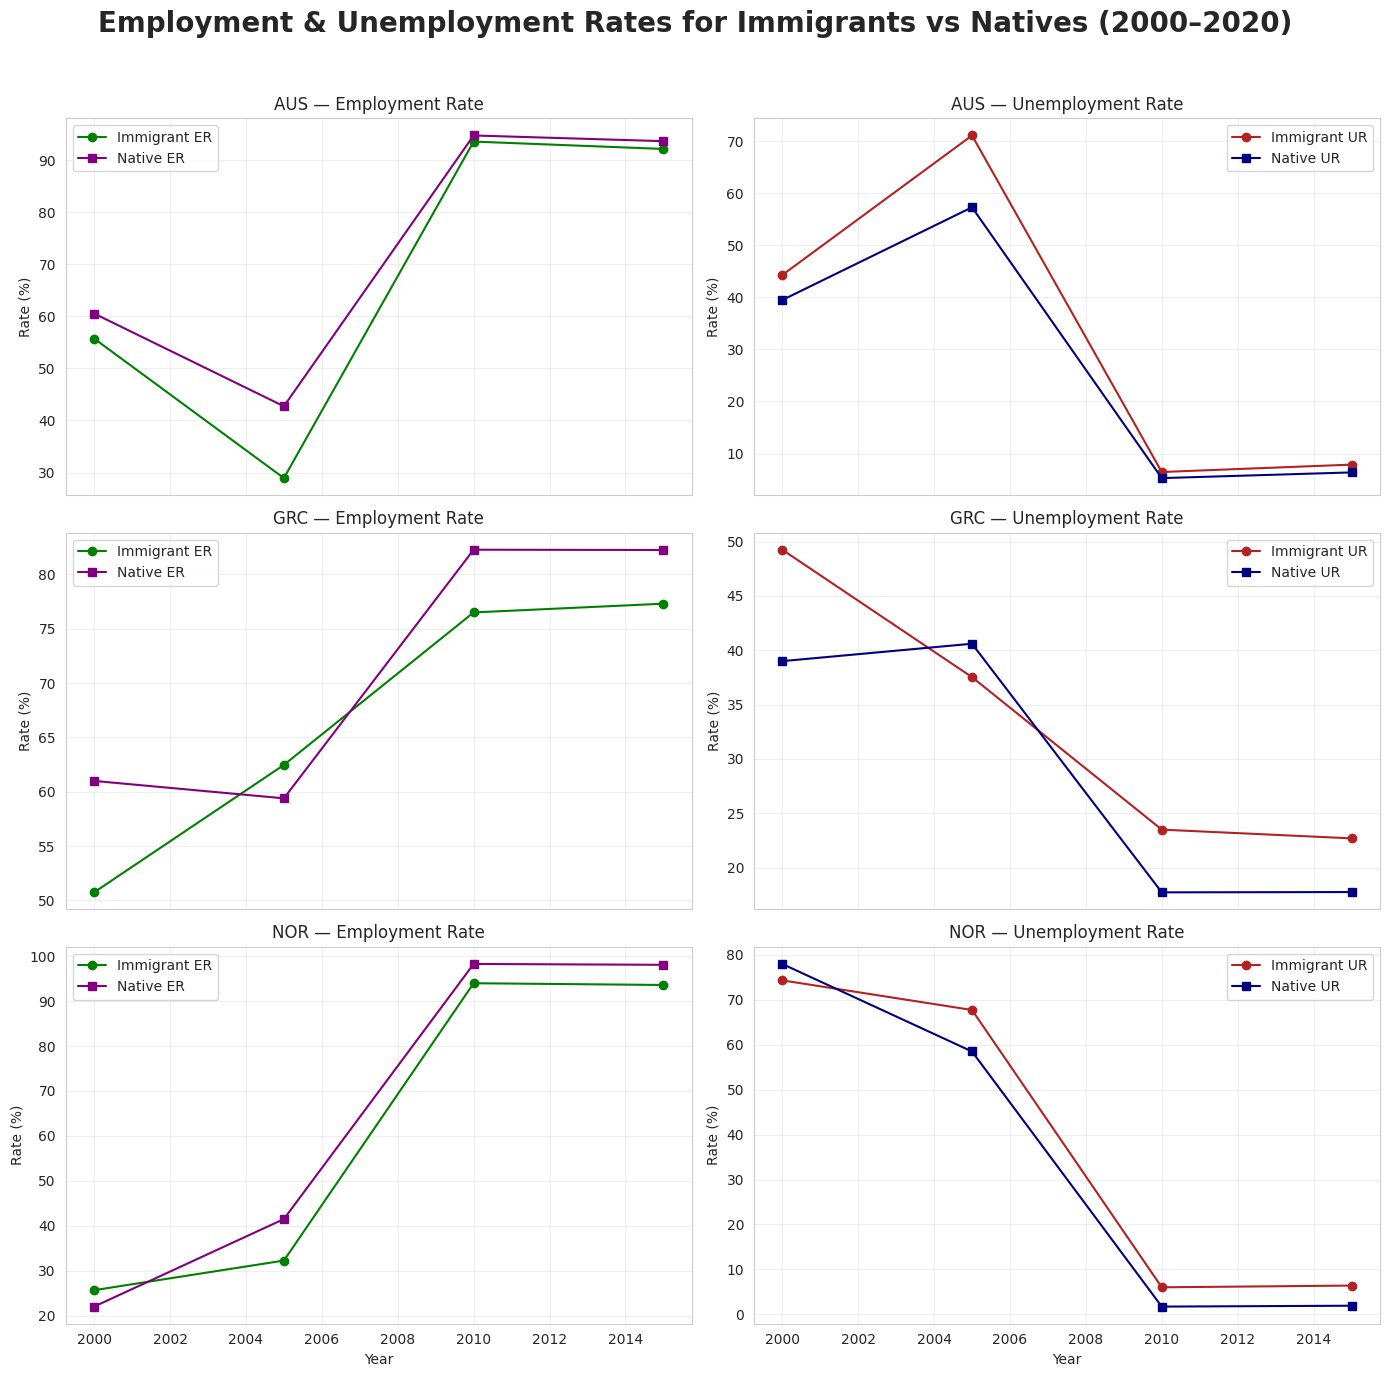

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# PATHS + COUNTRY LIST
# -----------------------------
base = "/content/drive/Shared drives/Case Study 6/DIOC Data"
countries = ["AUS", "GRC", "NOR"]

# Labour-force column varies by year
lfs_cols = {
    2000: "edu_lfs",
    2005: "edu_lfs",
    2010: "lfs",
    2015: "lfs",
    2020: "edu_lfs"
}

# -----------------------------
# CLEANING FUNCTION
# -----------------------------
def clean_dioc(df, year):
    # If "country" not present, rename "coub"
    if "country" not in df.columns and "coub" in df.columns:
        df = df.rename(columns={"coub": "country"})

    # nativity
    df["nativity"] = df["fborn"].map({1: "Immigrant", 0: "Native", 2: "Native"})

    # labour force status
    lfs_col = lfs_cols[year]
    df["lf_status"] = df[lfs_col].map({1: "Employed", 2: "Unemployed", 3: "Inactive"})

    df["year"] = year
    return df[["country", "nativity", "lf_status", "number", "year"]]


# -----------------------------
# LOAD ALL YEARS
# -----------------------------
dfs = []

# 2000
df2000 = pd.read_csv(os.path.join(base, "DIOC 2000-01", "FILE_C_T.csv"))
dfs.append(clean_dioc(df2000, 2000))

# 2005
t21 = pd.read_csv(os.path.join(base, "DIOC 2005-06", "T2.1_2005.CSV"))
t22 = pd.read_csv(os.path.join(base, "DIOC 2005-06", "T2.2_2005.CSV"))
df2005 = pd.concat([t21, t22], ignore_index=True)
dfs.append(clean_dioc(df2005, 2005))

# 2010
df2010 = pd.read_csv(os.path.join(base, "DIOC 2010-11", "DIOC_2010_11_File_C_quater_REV.csv"))
dfs.append(clean_dioc(df2010, 2010))

# 2015
c1 = pd.read_csv(os.path.join(base, "DIOC 2015-16", "DIOC_2015_16_File_C_1.csv"))
c2 = pd.read_csv(os.path.join(base, "DIOC 2015-16", "DIOC_2015_16_File_C_2.csv"))
df2015 = pd.concat([c1, c2], ignore_index=True)
dfs.append(clean_dioc(df2015, 2015))

# 2020
df2020 = pd.read_excel(os.path.join(base, "DIOC 2020-21", "t3_TOP100.xlsx"))
dfs.append(clean_dioc(df2020, 2020))

# -----------------------------
# BUILD PANEL
# -----------------------------
panel = pd.concat(dfs, ignore_index=True)
panel = panel[panel["country"].isin(countries)]

# -----------------------------
# AGGREGATE EMPLOYMENT DATA
# -----------------------------
agg = (
    panel.groupby(["country", "year", "nativity", "lf_status"], as_index=False)["number"]
    .sum()
)

pivot = agg.pivot_table(
    index=["country", "year", "nativity"],
    columns="lf_status",
    values="number",
    fill_value=0
).reset_index()

pivot["labour_force"] = pivot["Employed"] + pivot["Unemployed"]
pivot["unemployment_rate"] = pivot["Unemployed"] / pivot["labour_force"] * 100
pivot["employment_rate"] = pivot["Employed"] / pivot["labour_force"] * 100


# -----------------------------
# STACKED EMPLOYMENT + UNEMPLOYMENT PLOTS
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex='col')
fig.suptitle(
    "Employment & Unemployment Rates for Immigrants vs Natives (2000–2020)",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

for i, c in enumerate(countries):
    temp = pivot[pivot["country"] == c]

    # ====== EMPLOYMENT (LEFT COLUMN) ======
    ax_emp = axes[i, 0]
    ax_emp.plot(temp[temp["nativity"]=="Immigrant"]["year"],
                temp[temp["nativity"]=="Immigrant"]["employment_rate"],
                marker="o", color="green", label="Immigrant ER")
    ax_emp.plot(temp[temp["nativity"]=="Native"]["year"],
                temp[temp["nativity"]=="Native"]["employment_rate"],
                marker="s", color="purple", label="Native ER")

    ax_emp.set_title(f"{c} — Employment Rate")
    ax_emp.set_ylabel("Rate (%)")
    ax_emp.grid(alpha=0.3)
    ax_emp.legend()

    # ====== UNEMPLOYMENT (RIGHT COLUMN) ======
    ax_unemp = axes[i, 1]
    ax_unemp.plot(temp[temp["nativity"]=="Immigrant"]["year"],
                  temp[temp["nativity"]=="Immigrant"]["unemployment_rate"],
                  marker="o", color="firebrick", label="Immigrant UR")
    ax_unemp.plot(temp[temp["nativity"]=="Native"]["year"],
                  temp[temp["nativity"]=="Native"]["unemployment_rate"],
                  marker="s", color="navy", label="Native UR")

    ax_unemp.set_title(f"{c} — Unemployment Rate")
    ax_unemp.set_ylabel("Rate (%)")
    ax_unemp.grid(alpha=0.3)
    ax_unemp.legend()

# Label bottom x-axis
for j in range(2):
    axes[2, j].set_xlabel("Year")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Check education codes across all years
for year, df in [(2000, df2000), (2005, df2005), (2010, df2010), (2015, df2015), (2020, df2020)]:
    print(year, sorted(df["edu_lfs"].dropna().unique()))


2000 [np.int64(1), np.int64(2), np.int64(3), np.int64(99)]
2005 [np.int64(1), np.int64(2), np.int64(3), np.int64(99)]
2010 [np.int64(1), np.int64(2), np.int64(3), np.int64(99)]
2015 [np.int64(1), np.int64(2), np.int64(3), np.int64(99)]
2020 ['ISCED 0/1/2', 'ISCED 3/4', 'ISCED 5/6/7/8', 'Unknown']


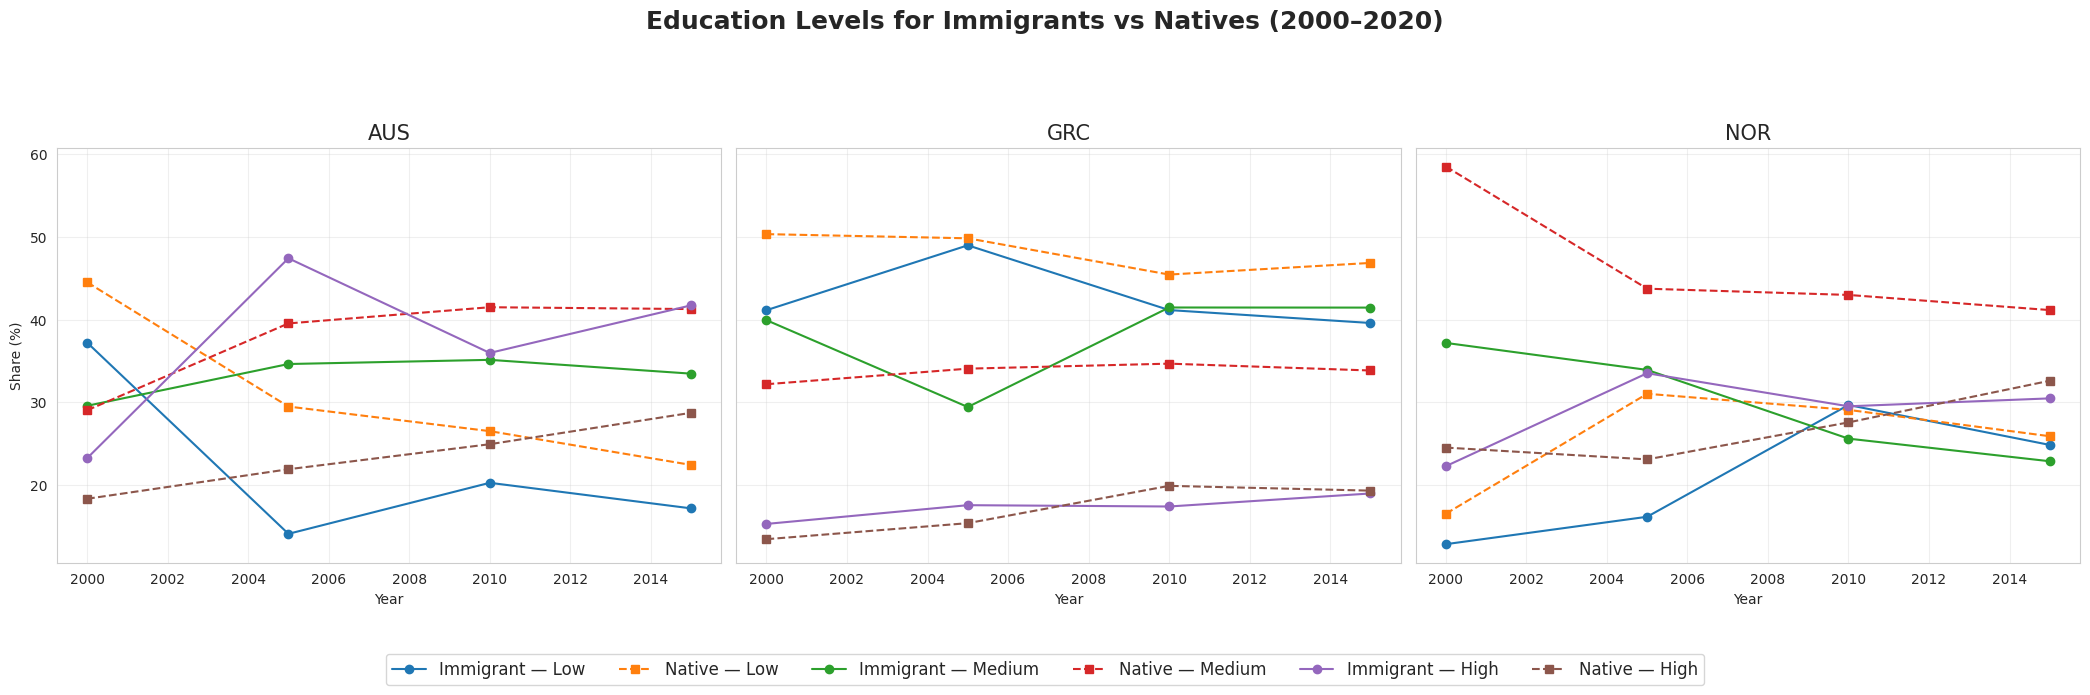

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------------------------
# PATHS + COUNTRY LIST
# ---------------------------------------
base = "/content/drive/Shared drives/Case Study 6/DIOC Data"
countries = ["AUS", "GRC", "NOR"]

# Labour-force status column by year
lfs_cols = {
    2000: "edu_lfs",
    2005: "edu_lfs",
    2010: "lfs",
    2015: "lfs",
    2020: "edu_lfs"
}

# ---------------------------------------
# CLEANING FUNCTION
# ---------------------------------------
def clean_dioc(df, year):
    # Fix country column
    if "country" not in df.columns and "coub" in df.columns:
        df = df.rename(columns={"coub": "country"})

    # nativity
    df["nativity"] = df["fborn"].map({1: "Immigrant", 0: "Native", 2: "Native"})

    # labour force status
    lfs_col = lfs_cols[year]
    df["lf_status"] = df[lfs_col].map({1: "Employed", 2: "Unemployed", 3: "Inactive"})

    df["year"] = year

    # KEEP EDUCATION COLUMN
    return df[["country", "nativity", "lf_status", "edu_lfs", "number", "year"]]


# ---------------------------------------
# LOAD ALL YEARS
# ---------------------------------------
dfs = []

# 2000
df2000 = pd.read_csv(os.path.join(base, "DIOC 2000-01", "FILE_C_T.csv"))
dfs.append(clean_dioc(df2000, 2000))

# 2005 (two files)
t21 = pd.read_csv(os.path.join(base, "DIOC 2005-06", "T2.1_2005.CSV"))
t22 = pd.read_csv(os.path.join(base, "DIOC 2005-06", "T2.2_2005.CSV"))
df2005 = pd.concat([t21, t22], ignore_index=True)
dfs.append(clean_dioc(df2005, 2005))

# 2010
df2010 = pd.read_csv(os.path.join(base, "DIOC 2010-11", "DIOC_2010_11_File_C_quater_REV.csv"))
dfs.append(clean_dioc(df2010, 2010))

# 2015
c1 = pd.read_csv(os.path.join(base, "DIOC 2015-16", "DIOC_2015_16_File_C_1.csv"))
c2 = pd.read_csv(os.path.join(base, "DIOC 2015-16", "DIOC_2015_16_File_C_2.csv"))
df2015 = pd.concat([c1, c2], ignore_index=True)
dfs.append(clean_dioc(df2015, 2015))

# 2020
df2020 = pd.read_excel(os.path.join(base, "DIOC 2020-21", "t3_TOP100.xlsx"))
dfs.append(clean_dioc(df2020, 2020))

# ---------------------------------------
# BUILD PANEL
# ---------------------------------------
panel = pd.concat(dfs, ignore_index=True)
panel = panel[panel["country"].isin(countries)]


# ---------------------------------------
# STANDARDIZE 2020 EDUCATION CODES
# ---------------------------------------
edu2020_map = {
    "ISCED 0/1/2": 1,
    "ISCED 3/4": 2,
    "ISCED 5/6/7/8": 3,
    "Unknown": 99
}

panel.loc[panel["year"] == 2020, "edu_lfs"] = (
    panel.loc[panel["year"] == 2020, "edu_lfs"].map(edu2020_map)
)

# Convert to numeric
panel["edu_lfs"] = pd.to_numeric(panel["edu_lfs"], errors="coerce")


# ---------------------------------------
# COMPUTE EDUCATION SHARES
# ---------------------------------------
edu_agg = (
    panel.groupby(["country", "year", "nativity", "edu_lfs"], as_index=False)["number"]
    .sum()
)

# totals per group
tot = edu_agg.groupby(["country", "year", "nativity"])["number"].sum().reset_index()
tot = tot.rename(columns={"number": "total"})
edu_agg = edu_agg.merge(tot, on=["country", "year", "nativity"])

edu_agg["share"] = edu_agg["number"] / edu_agg["total"] * 100

# keep only low/medium/high
edu_agg = edu_agg[edu_agg["edu_lfs"].isin([1, 2, 3])]

edu_labels = {1: "Low", 2: "Medium", 3: "High"}


# ---------------------------------------
# PLOT: Option D — 3-panel (AUS | GRC | NOR)
# ---------------------------------------
# ---------------------------------------
# PLOT: Option D — 3-panel (AUS | GRC | NOR)
# ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
fig.suptitle("Education Levels for Immigrants vs Natives (2000–2020)",
             fontsize=18, fontweight="bold", y=1.02)

for ax, c in zip(axes, countries):
    temp = edu_agg[edu_agg["country"] == c]

    for edu_code in [1, 2, 3]:
        # immigrants (solid)
        ax.plot(
            temp[(temp["nativity"]=="Immigrant") & (temp["edu_lfs"]==edu_code)]["year"],
            temp[(temp["nativity"]=="Immigrant") & (temp["edu_lfs"]==edu_code)]["share"],
            marker="o",
            label=f"Immigrant — {edu_labels[edu_code]}"
        )
        # natives (dashed)
        ax.plot(
            temp[(temp["nativity"]=="Native") & (temp["edu_lfs"]==edu_code)]["year"],
            temp[(temp["nativity"]=="Native") & (temp["edu_lfs"]==edu_code)]["share"],
            marker="s",
            linestyle="--",
            label=f"Native — {edu_labels[edu_code]}"
        )

    ax.set_title(c, fontsize=15)
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Share (%)")

# SINGLE GLOBAL LEGEND ONLY
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.12), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()



| Code   | Education Level      | Meaning                               |
| ------ | -------------------- | ------------------------------------- |
| **1**  | **Low education**    | Primary education or below            |
| **2**  | **Medium education** | Lower & upper secondary education     |
| **3**  | **High education**   | Tertiary / university-level education |
| **99** | Missing              | Not classified                        |


# Share of High-Skill Migrants (Tertiary Education)

In [ ]:
import pandas as pd
import os

base = "/content/drive/Shared drives/Case Study 6/DIOC Data"
countries = ["AUS", "GRC", "NOR"]

lfs_cols = {
    2000: "edu_lfs",
    2005: "edu_lfs",
    2010: "lfs",
    2015: "lfs",
    2020: "edu_lfs"
}

def clean_dioc(df, year):
    if "country" not in df.columns and "coub" in df.columns:
        df = df.rename(columns={"coub": "country"})
    df["nativity"] = df["fborn"].map({1: "Immigrant", 0: "Native", 2: "Native"})
    df["lf_status"] = df[lfs_cols[year]].map({1: "Employed", 2: "Unemployed", 3: "Inactive"})
    df["year"] = year
    return df[["country", "nativity", "lf_status", "edu_lfs", "number", "year"]]

dfs = []

# 2000
df2000 = pd.read_csv(os.path.join(base, "DIOC 2000-01", "FILE_C_T.csv"))
dfs.append(clean_dioc(df2000, 2000))

# 2005
t21 = pd.read_csv(os.path.join(base, "DIOC 2005-06", "T2.1_2005.CSV"))
t22 = pd.read_csv(os.path.join(base, "DIOC 2005-06", "T2.2_2005.CSV"))
dfs.append(clean_dioc(pd.concat([t21, t22]), 2005))

# 2010
df2010 = pd.read_csv(os.path.join(base, "DIOC 2010-11", "DIOC_2010_11_File_C_quater_REV.csv"))
dfs.append(clean_dioc(df2010, 2010))

# 2015
c1 = pd.read_csv(os.path.join(base, "DIOC 2015-16", "DIOC_2015_16_File_C_1.csv"))
c2 = pd.read_csv(os.path.join(base, "DIOC 2015-16", "DIOC_2015_16_File_C_2.csv"))
dfs.append(clean_dioc(pd.concat([c1, c2]), 2015))

# 2020
df2020 = pd.read_excel(os.path.join(base, "DIOC 2020-21", "t3_TOP100.xlsx"))
dfs.append(clean_dioc(df2020, 2020))

panel = pd.concat(dfs, ignore_index=True)
panel = panel[panel["country"].isin(countries)]

# fix 2020 edu_lfs
edu2020_map = {"ISCED 0/1/2": 1, "ISCED 3/4": 2, "ISCED 5/6/7/8": 3, "Unknown": 99}
panel.loc[panel["year"] == 2020, "edu_lfs"] = \
    panel.loc[panel["year"] == 2020, "edu_lfs"].map(edu2020_map)
panel["edu_lfs"] = pd.to_numeric(panel["edu_lfs"], errors="coerce")

print(panel.head())


   country   nativity   lf_status  edu_lfs  number  year
0      GRC  Immigrant    Inactive        3     1.0  2000
1      AUS  Immigrant    Inactive        3     8.0  2000
10     GRC  Immigrant    Employed        1     5.0  2000
24     GRC  Immigrant  Unemployed        2     7.0  2000
26     GRC  Immigrant  Unemployed        2     4.0  2000


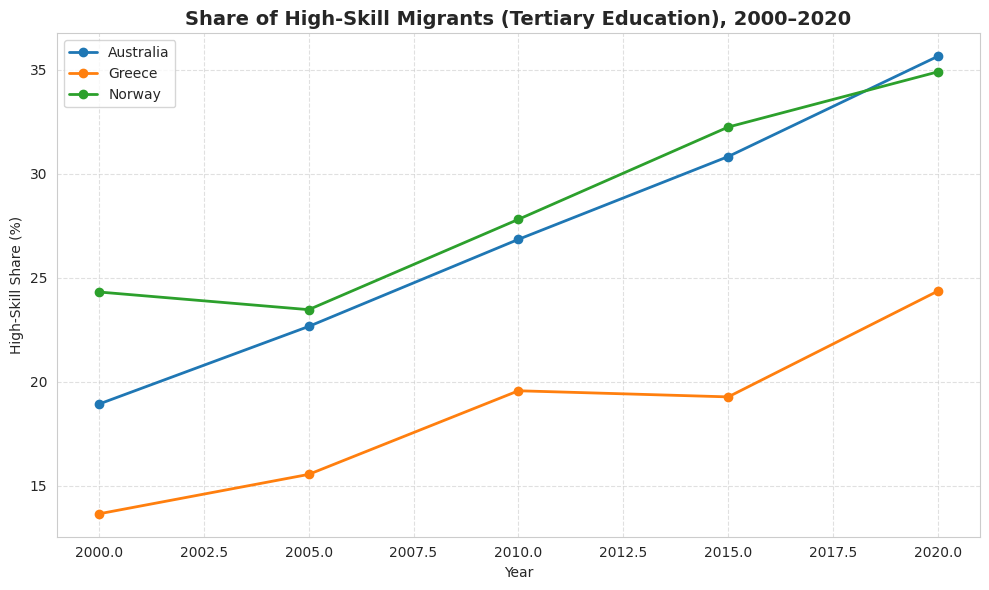

In [ ]:
# ============================================================
# TIME-SERIES VISUAL: SHARE OF HIGH-SKILL (TERTIARY) MIGRANTS
# ============================================================

import matplotlib.pyplot as plt

# 1. Filter to high-skilled (edu_lfs = 3)
high_skill = panel[panel["edu_lfs"] == 3].copy()

# 2. Sum counts
high_skill_agg = high_skill.groupby(["country", "year"], as_index=False)["number"].sum()

# 3. Totals
year_totals = panel.groupby(["country", "year"], as_index=False)["number"].sum()
year_totals = year_totals.rename(columns={"number": "total"})

# 4. Compute share
high_skill_merged = high_skill_agg.merge(year_totals, on=["country", "year"])
high_skill_merged["high_skill_share"] = \
    (high_skill_merged["number"] / high_skill_merged["total"]) * 100

# 5. Plot
countries = ["AUS", "GRC", "NOR"]
labels = {"AUS": "Australia", "GRC": "Greece", "NOR": "Norway"}

plt.figure(figsize=(10,6))
for c in countries:
    temp = high_skill_merged[high_skill_merged["country"] == c]
    plt.plot(temp["year"], temp["high_skill_share"], marker="o", linewidth=2, label=labels[c])

plt.title("Share of High-Skill Migrants (Tertiary Education), 2000–2020",
          fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("High-Skill Share (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# 1. Total Migration Inflows Over Time (OECD Aggregate)

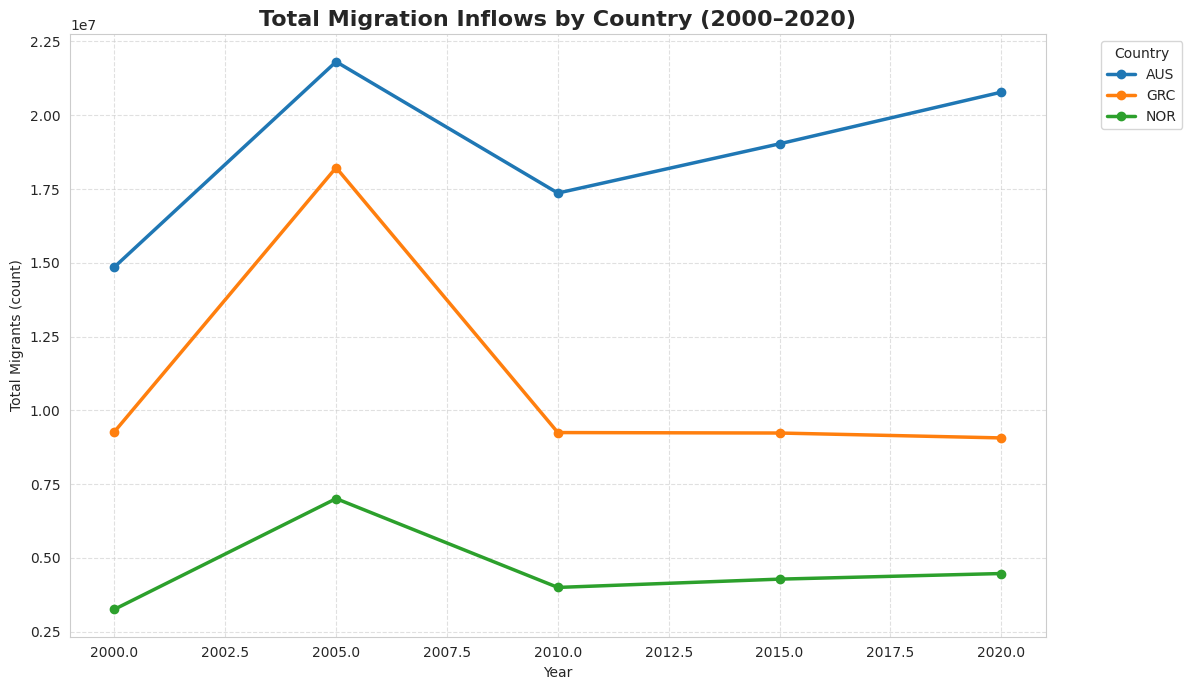

In [ ]:
  # ---- Q1 EXTENDED: TOTAL MIGRATION INFLOWS SEPARATED BY COUNTRY ----

import matplotlib.pyplot as plt

# Aggregate total inflows per country per year
country_totals = panel.groupby(["country", "year"], as_index=False)["number"].sum()

# Pivot for plotting
country_pivot = country_totals.pivot(index="year", columns="country", values="number")

plt.figure(figsize=(12,7))

for country in country_pivot.columns:
    plt.plot(country_pivot.index,
             country_pivot[country],
             marker="o",
             linewidth=2.5,
             label=country)

plt.title("Total Migration Inflows by Country (2000–2020)",
          fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Migrants (count)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Country", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()
